## Soundsensing data example

Real-world acoustic monitoring data from Soundsensing: equivalent continuous
A-weighted sound pressure level (`leq`, in dB) from 8 measurement devices,
sampled roughly once per minute over ~2 years (2024-05 to 2026-05).

The raw stream is ~1M points per device, so we load it once and aggregate to a
coarser median for plotting. See `soundsensing/README.txt` for details (data is
confidential — do not redistribute raw values).

In [1]:
# Load the Soundsensing data
# =============================================================================
from pathlib import Path
import pandas as pd

# Resolve the parquet path relative to this notebook (works regardless of cwd).
DATA_PATH = Path("soundsensing/data.parquet")
if not DATA_PATH.exists():
    DATA_PATH = Path("old_notebooks/soundsensing/data.parquet")

ss = pd.read_parquet(DATA_PATH)  # MultiIndex: (device_id, end_time), column: leq
device_ids = ss.index.get_level_values("device_id").unique().tolist()

print(f"{ss.shape[0]:,} rows, {len(device_ids)} devices")
print("time range:", ss.index.get_level_values("end_time").min(),
      "->", ss.index.get_level_values("end_time").max())
ss.head()

7,790,229 rows, 8 devices
time range: 2024-05-01 00:00:00 -> 2026-05-01 23:59:51


leq
device_id                            end_time                 
20c92dca-6617-4a01-a461-3c33fe2ce407 2024-05-01 00:00:41  51.0
                                     2024-05-01 00:01:45  51.0
                                     2024-05-01 00:02:49  50.0
                                     2024-05-01 00:03:53  51.0
                                     2024-05-01 00:04:57  50.0

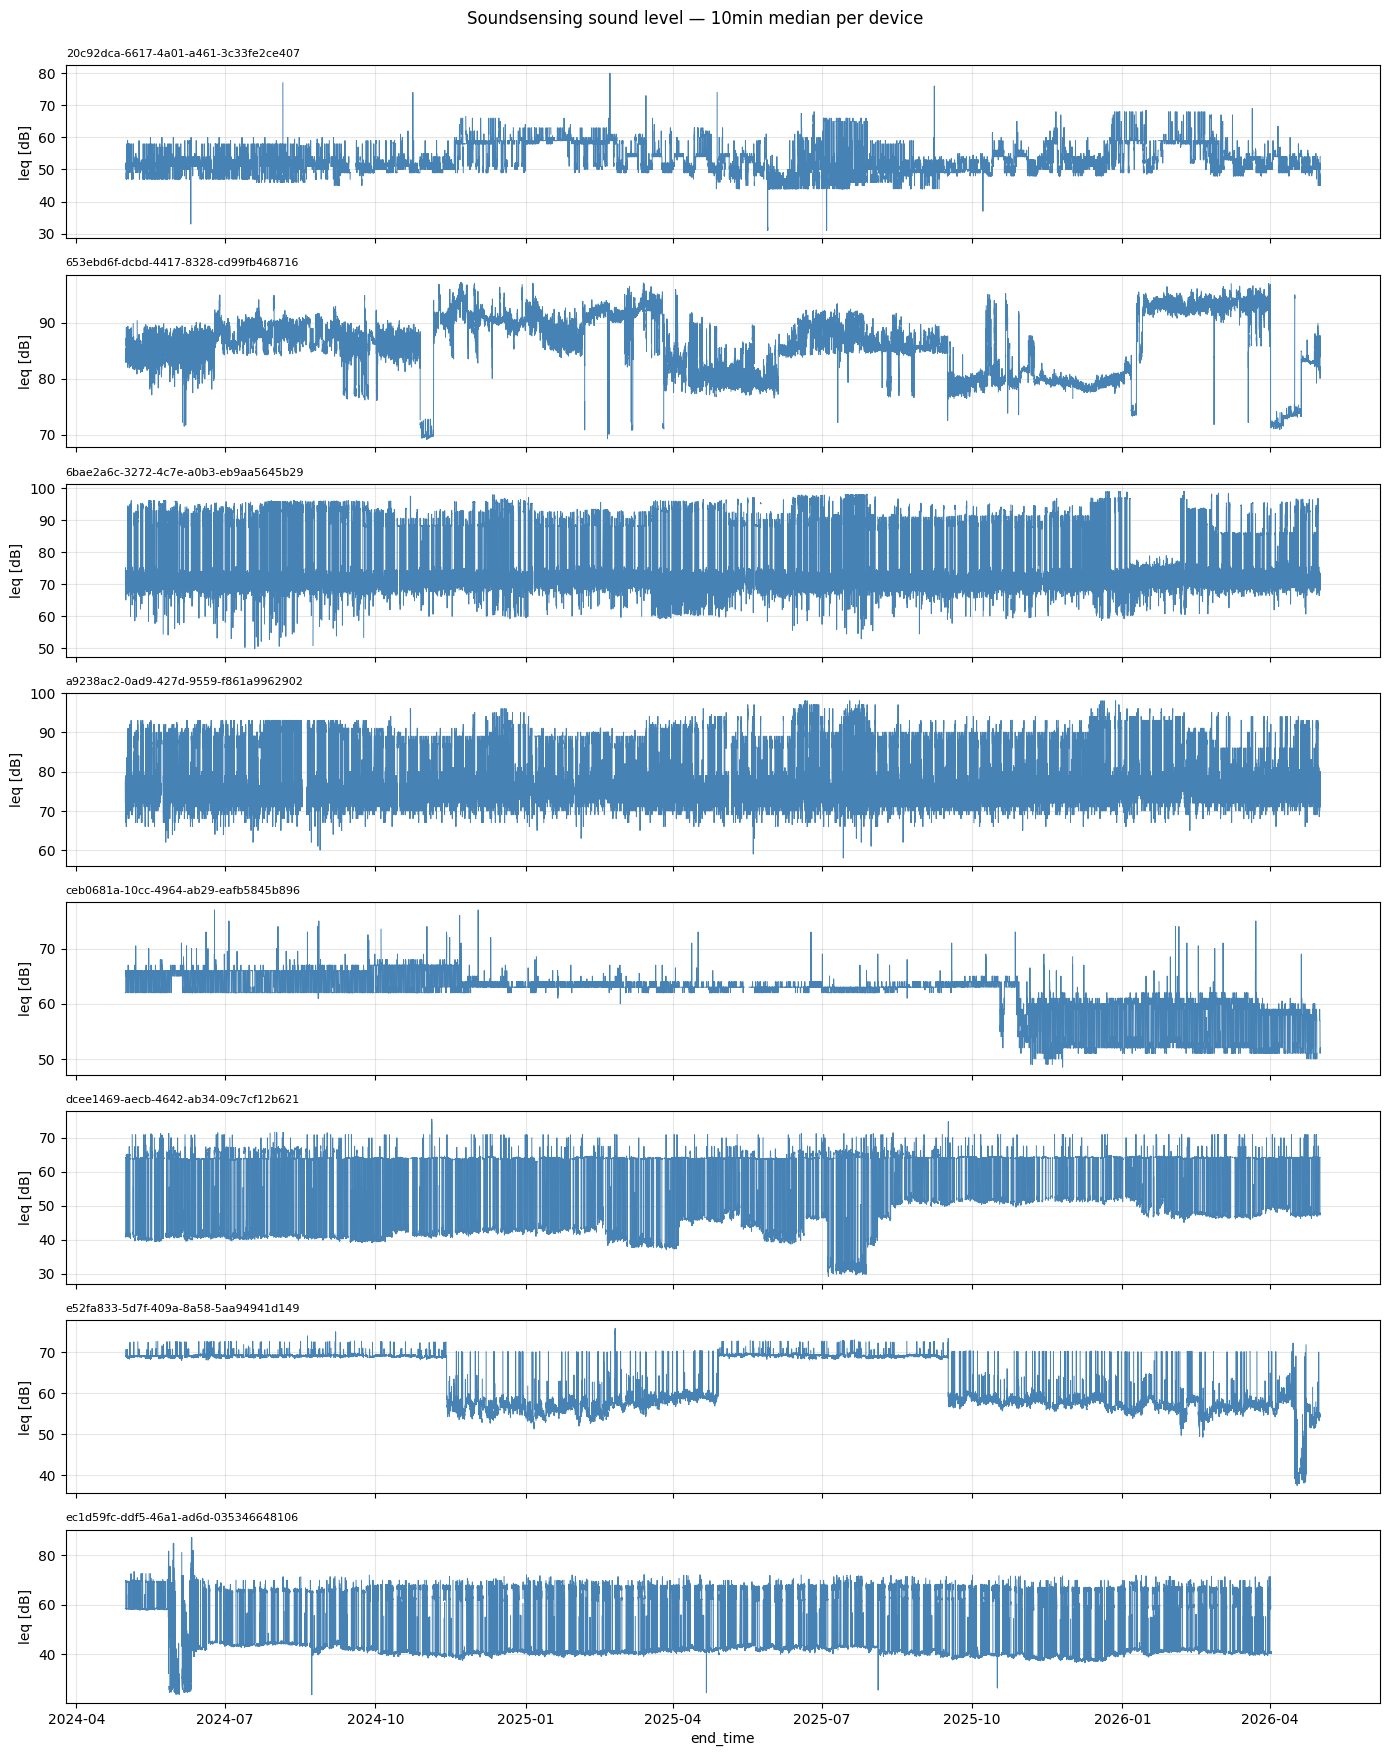

In [2]:
# Plot the data — one subplot per device (10-min median aggregation)
# =============================================================================
import matplotlib.pyplot as plt

AGG = "10min"  # non-overlapping median windows (per data provider's suggestion)

resampled = (
    ss.groupby("device_id", observed=True)
    .resample(AGG, level="end_time")
    .median()
)

fig, axes = plt.subplots(
    len(device_ids), 1, figsize=(14, 2.2 * len(device_ids)), sharex=True
)
for ax, dev in zip(axes, device_ids):
    s = resampled.xs(dev, level="device_id")["leq"]
    ax.plot(s.index, s.values, color="steelblue", linewidth=0.7)
    ax.set_ylabel("leq [dB]")
    ax.set_title(str(dev), fontsize=8, loc="left")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("end_time")
fig.suptitle(f"Soundsensing sound level — {AGG} median per device", y=0.995)
fig.tight_layout()
plt.show()

### Changepoint detection with `gridcp`

We run the online detector on each device's 10-min median stream. The four
selected devices show a daily on/off pattern (~2 changepoints per weekday), so
we detect *multiple* changepoints sequentially: on each alarm we reset the
detector at the estimated changepoint and replay the samples since then (no data
discarded between changepoints).

- **Score:** `MeanCUSUMUnknownVariance` — detects mean shifts while estimating
  the noise level online (day vs. night dB levels differ per device).
- **Threshold:** calibrated by circular block bootstrap on a *change-free*
  baseline. This matters: the baseline must contain no changepoint. We use
  `quiet_floor`, which picks samples from the hours near each device's daily
  minimum (its "off" state), adapting to the device's own schedule. Calibrating
  on a full day instead folds the daily jump into the noise estimate, inflating
  the threshold and silencing the cleanest (low-noise) devices.
- **Parallelism:** `parallel=False` — spawn-based multiprocessing is unreliable
  inside notebooks on this Python/macOS build.

In [4]:
# Setup: imports and the change-free baseline helper
# =============================================================================
import numpy as np
from gridcp import (
    GridDetector,
    calibrate_detector_threshold_false_alarm_from_data,
    with_calibrated_threshold,
    calibrate_detector_threshold_arl_from_data,
)
from gridcp.scores import MeanCUSUMUnknownVariance


def quiet_floor(window, *, n=48, margin=3.0):
    """Change-free calibration baseline: ``n`` samples drawn from the hours
    whose typical level sits within ``margin`` dB of the daily minimum (the
    device's "off" state). Adapts to each device's on/off schedule, unlike a
    fixed clock window — e.g. one device switches on at 04:00, another at 08:00."""
    by_hour = window.groupby(window.index.hour).median()
    quiet_hours = by_hour[by_hour <= by_hour.min() + margin].index
    quiet = window[np.isin(window.index.hour, quiet_hours)]
    return quiet.iloc[:n].values.astype(float)

/Users/espen/Desktop/PhD/G-CHAD/gridcp/calibration.py:1938: UserWarning: training_data has 48 observations but stream_len=144. The circular block bootstrap will wrap around, but calibration may be unreliable with so few training observations.
  return calibrate_threshold_false_alarm_from_data(


a9238ac2: 1138 samples, 13 changepoints, thr=13.13


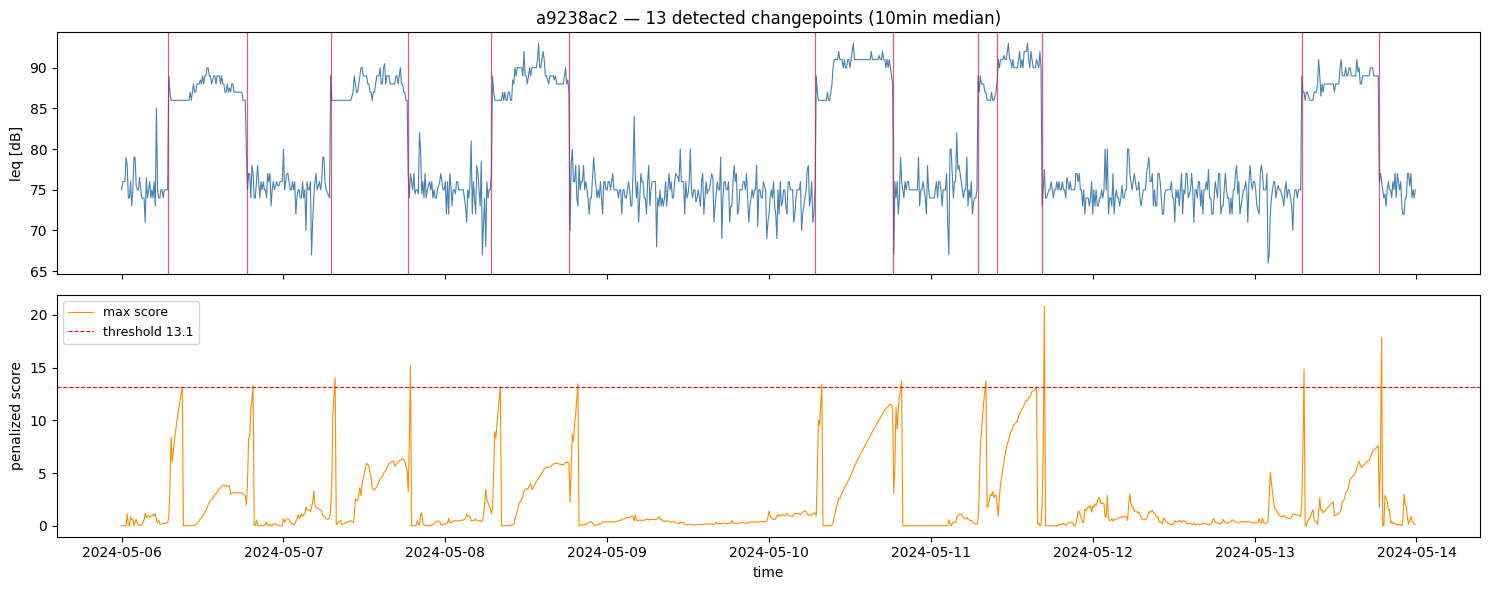

In [4]:
# Detect changepoints on one device (data + score trace)
# =============================================================================
DEVICE_PREFIX = "a9238"          # one of the four daily-pattern devices
WINDOW = ("2024-05-06", "2024-05-13")  # ~1 week

dev = next(d for d in device_ids if d.startswith(DEVICE_PREFIX))
series = ss.xs(dev, level="device_id")["leq"].resample(AGG).median()
window = series[WINDOW[0] : WINDOW[1]].dropna()  # drop gaps
times, data = window.index, window.values.astype(float)

# --- Calibrate the alarm threshold: circular block bootstrap on the change-free
#     quiet-night baseline, controlling false alarms over a 1-day horizon. ---
score = MeanCUSUMUnknownVariance()
detector = GridDetector(score)
threshold = calibrate_detector_threshold_false_alarm_from_data(
    detector,
    training_data=quiet_floor(window),
    false_alarm_probability=0.01,
    stream_len=144,        # false-alarm horizon = 1 day at 10-min sampling
    n_paths=500,
    rng=42,
    parallel=False,        # spawn-based parallelism is unreliable in notebooks here
)
detector = with_calibrated_threshold(detector, threshold)
thr = float(threshold[0])  # scalar threshold for a 1-D score

# --- Online detection: at each alarm, reset at the estimated changepoint and
#     replay the samples since then (no data discarded between changepoints). ---
state = detector.init_state()
offset = 0
cps, scores = [], []
for i in range(len(data)):
    state, out = detector.update(state, np.array([data[i]]))
    scores.append(float(out["max_score"][0]))
    if out["alarm"]:
        cp = offset + int(out["max_split_point"][0])
        cps.append(cp)
        offset = cp
        state = detector.init_state()
        for x in data[cp : i + 1]:
            state, _ = detector.update(state, np.array([x]))

print(f"{dev[:8]}: {len(data)} samples, {len(cps)} changepoints, thr={thr:.2f}")

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axes[0].plot(times, data, color="steelblue", lw=0.8)
for c in cps:
    axes[0].axvline(times[c], color="crimson", lw=0.9, alpha=0.7)
axes[0].set_ylabel("leq [dB]")
axes[0].set_title(f"{dev[:8]} \u2014 {len(cps)} detected changepoints ({AGG} median)")

axes[1].plot(times, scores, color="darkorange", lw=0.8, label="max score")
axes[1].axhline(thr, ls="--", color="red", lw=0.8, label=f"threshold {thr:.1f}")
axes[1].set_ylabel("penalized score")
axes[1].set_xlabel("time")
axes[1].legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

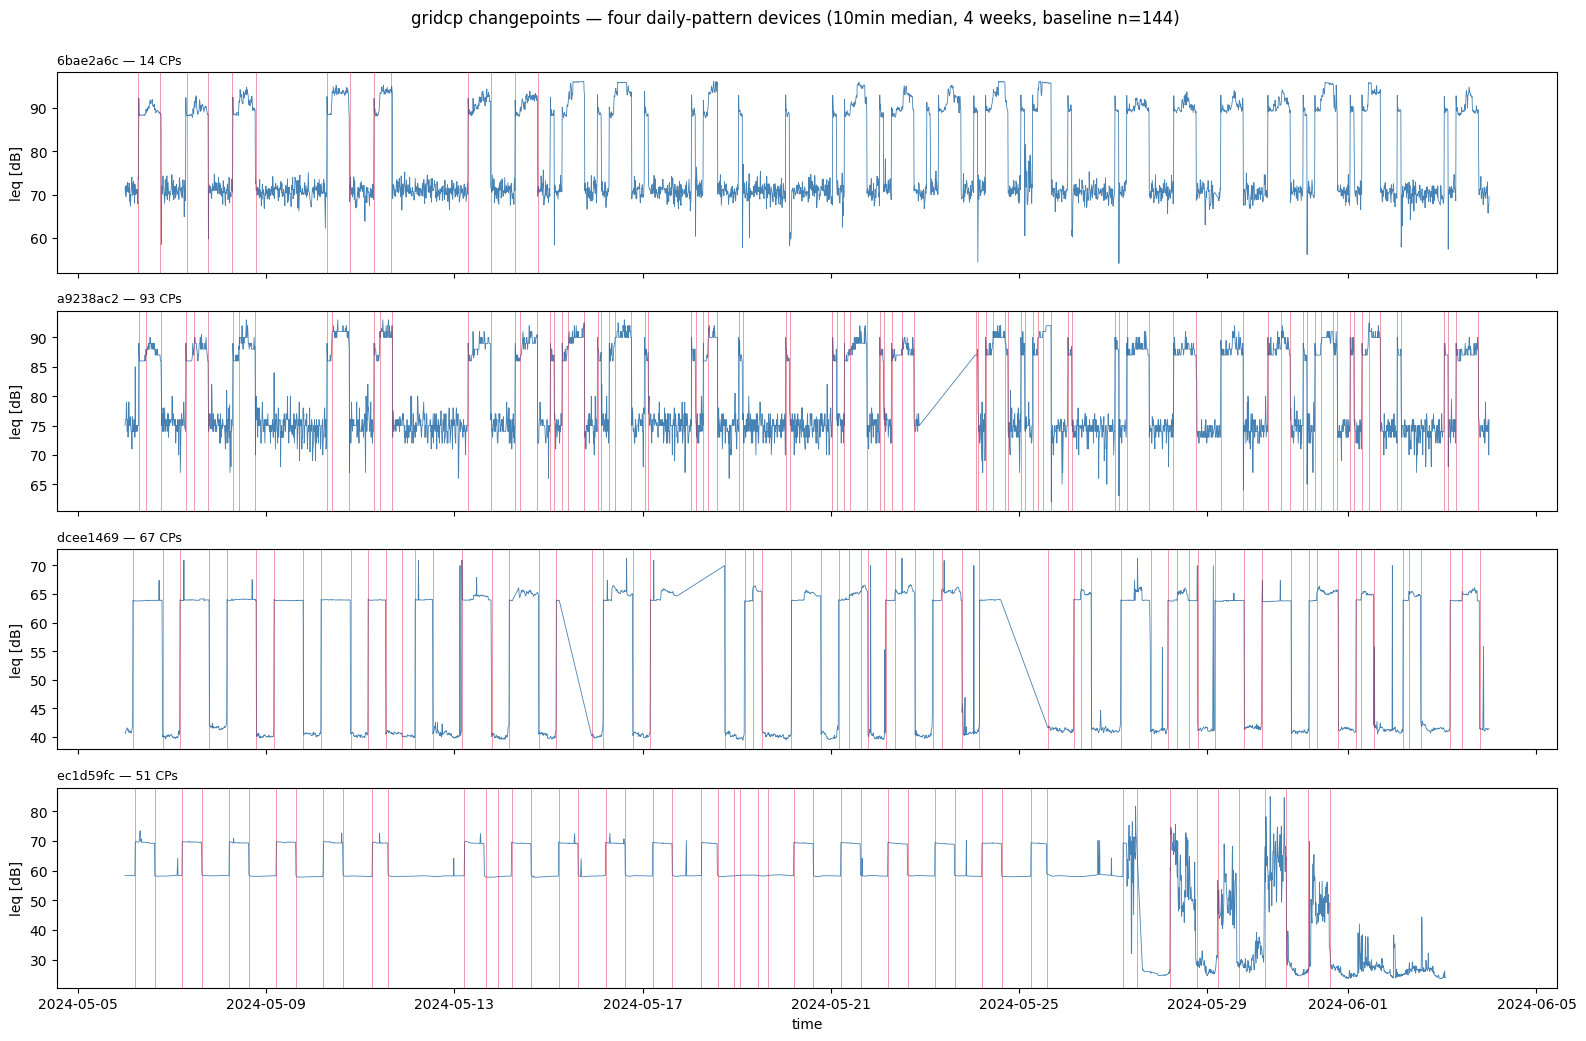

In [5]:
# Run on all four daily-pattern devices (4-week window, larger baseline)
# =============================================================================
TARGET_PREFIXES = ("6bae2", "a9238", "dcee1", "ec1d5")
targets = [next(d for d in device_ids if d.startswith(p)) for p in TARGET_PREFIXES]

OV_WINDOW = ("2024-05-06", "2024-06-03")  # 4 weeks of data
BASELINE_N = 144       # longer change-free baseline (>= stream_len -> no wrap)
BASELINE_MARGIN = 1.5  # tighter than default to exclude shoulder/transition hours

fig, axes = plt.subplots(len(targets), 1, figsize=(16, 2.6 * len(targets)), sharex=True)
for ax, dev in zip(axes, targets):
    series = ss.xs(dev, level="device_id")["leq"].resample(AGG).median()
    window = series[OV_WINDOW[0] : OV_WINDOW[1]].dropna()
    times, data = window.index, window.values.astype(float)

    # Calibrate on this device's quiet-night baseline (n=144 samples).
    detector = GridDetector(MeanCUSUMUnknownVariance())
    threshold = calibrate_detector_threshold_false_alarm_from_data(
        detector,
        training_data=quiet_floor(window, n=BASELINE_N, margin=BASELINE_MARGIN),
        false_alarm_probability=0.01,
        stream_len=144,
        n_paths=500,
        rng=42,
        parallel=False,
    )
    detector = with_calibrated_threshold(detector, threshold)

    # Online detection with reset-and-replay at each estimated changepoint.
    state = detector.init_state()
    offset = 0
    cps = []
    for i in range(len(data)):
        state, out = detector.update(state, np.array([data[i]]))
        if out["alarm"]:
            cp = offset + int(out["max_split_point"][0])
            cps.append(cp)
            offset = cp
            state = detector.init_state()
            for x in data[cp : i + 1]:
                state, _ = detector.update(state, np.array([x]))

    ax.plot(times, data, color="steelblue", lw=0.6)
    for c in cps:
        ax.axvline(times[c], color="crimson", lw=0.6, alpha=0.5)
    ax.set_ylabel("leq [dB]")
    ax.set_title(f"{dev[:8]} — {len(cps)} CPs", fontsize=9, loc="left")
axes[-1].set_xlabel("time")
fig.suptitle(f"gridcp changepoints — four daily-pattern devices "
             f"({AGG} median, 4 weeks, baseline n={BASELINE_N})", y=0.997)
fig.tight_layout()
plt.show()

### Full stream and zoom

The 1-week views above are zoomed in. Here we run the detector once over a
device's **entire ~2-year stream** (~100k 10-min points; calibration + detection
take ~2 s total), then show the full series and a 1-week zoom drawn from the
*same* run. At full scale the ~1700 changepoint markers blur into a wash — it
shows coverage; the zoom shows that the alarms land on the daily transitions.

/Users/espen/Desktop/PhD/G-CHAD/gridcp/calibration.py:1938: UserWarning: training_data has 48 observations but stream_len=144. The circular block bootstrap will wrap around, but calibration may be unreliable with so few training observations.
  return calibrate_threshold_false_alarm_from_data(


a9238ac2: 102,976 samples over 2024-05-01..2026-05-01, 1735 changepoints, thr=6.37


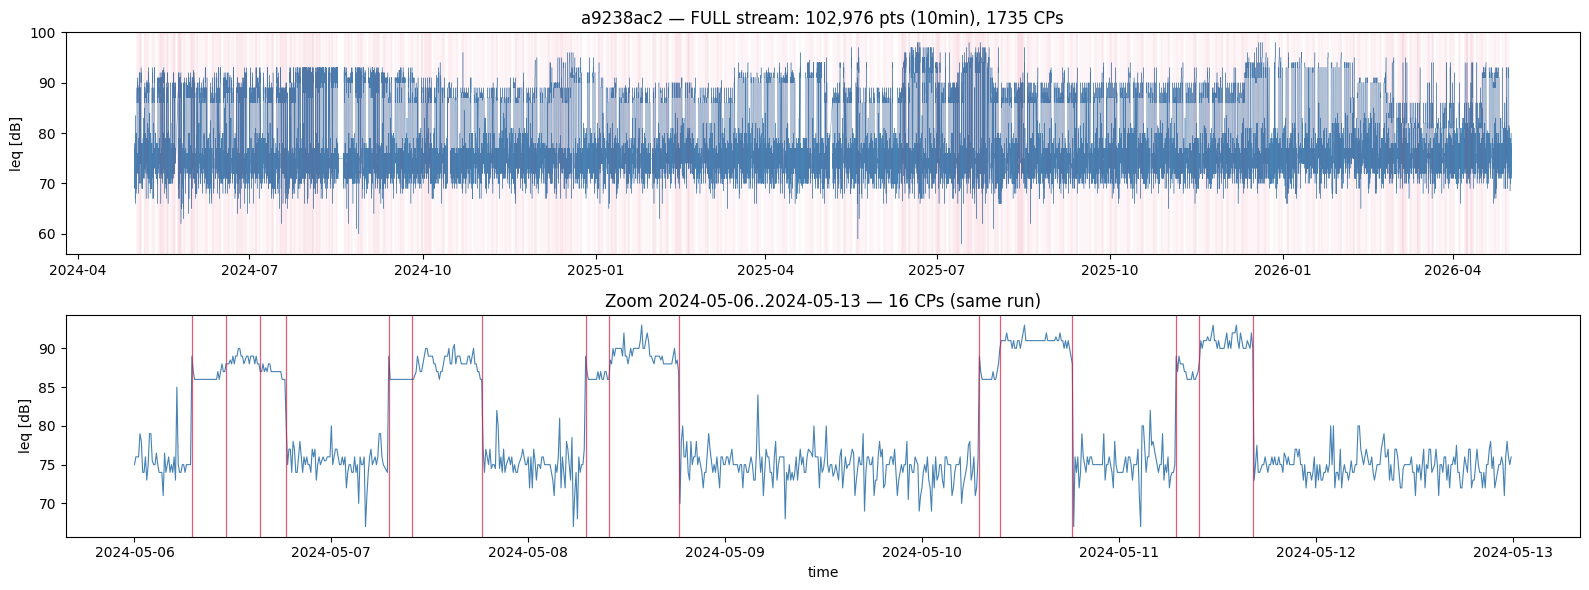

In [6]:
# Full stream + zoom (one device, single detection run)
# =============================================================================
dev = next(d for d in device_ids if d.startswith("a9238"))
full = ss.xs(dev, level="device_id")["leq"].resample(AGG).median().dropna()
ft, fd = full.index, full.values.astype(float)

# Calibrate on the quiet floor of the first two days, then detect over the whole stream.
first_two_days = full[: ft[0].normalize() + pd.Timedelta(days=2)]
detector = GridDetector(MeanCUSUMUnknownVariance())
threshold = calibrate_detector_threshold_false_alarm_from_data(
    detector,
    training_data=quiet_floor(first_two_days),
    false_alarm_probability=0.01,
    stream_len=144,
    n_paths=500,
    rng=42,
    parallel=False,
)
detector = with_calibrated_threshold(detector, threshold)
thr = float(threshold[0])

state = detector.init_state()
offset = 0
cps = []
for i in range(len(fd)):
    state, out = detector.update(state, np.array([fd[i]]))
    if out["alarm"]:
        cp = offset + int(out["max_split_point"][0])
        cps.append(cp)
        offset = cp
        state = detector.init_state()
        for x in fd[cp : i + 1]:
            state, _ = detector.update(state, np.array([x]))

print(f"{dev[:8]}: {len(fd):,} samples over {ft[0].date()}..{ft[-1].date()}, "
      f"{len(cps)} changepoints, thr={thr:.2f}")

ZOOM = ("2024-05-06", "2024-05-13")
zmask = (ft >= pd.Timestamp(ZOOM[0])) & (ft < pd.Timestamp(ZOOM[1]))
zi = np.where(zmask)[0]
zcps = [c for c in cps if zi[0] <= c <= zi[-1]]

fig, axes = plt.subplots(2, 1, figsize=(16, 6))
axes[0].plot(ft, fd, color="steelblue", lw=0.3)
for c in cps:
    axes[0].axvline(ft[c], color="crimson", lw=0.25, alpha=0.12)
axes[0].set_ylabel("leq [dB]")
axes[0].set_title(f"{dev[:8]} — FULL stream: {len(fd):,} pts ({AGG}), {len(cps)} CPs")

axes[1].plot(ft[zmask], fd[zmask], color="steelblue", lw=0.8)
for c in zcps:
    axes[1].axvline(ft[c], color="crimson", lw=0.9, alpha=0.7)
axes[1].set_ylabel("leq [dB]")
axes[1].set_xlabel("time")
axes[1].set_title(f"Zoom {ZOOM[0]}..{ZOOM[1]} — {len(zcps)} CPs (same run)")
fig.tight_layout()
plt.show()

### Train / test split

For each daily-variation device we hold out the first `TRAIN_DAYS` as a
**training period** (gold) — only its `quiet_floor` is used to calibrate the
threshold — and run detection on the remaining **test period** (blue). This keeps
calibration and evaluation on disjoint data. The four devices have different
on/off schedules, which is exactly why the level-based `quiet_floor` baseline is
needed (a fixed clock window catches the early-rising device's transition and
inflates its threshold).

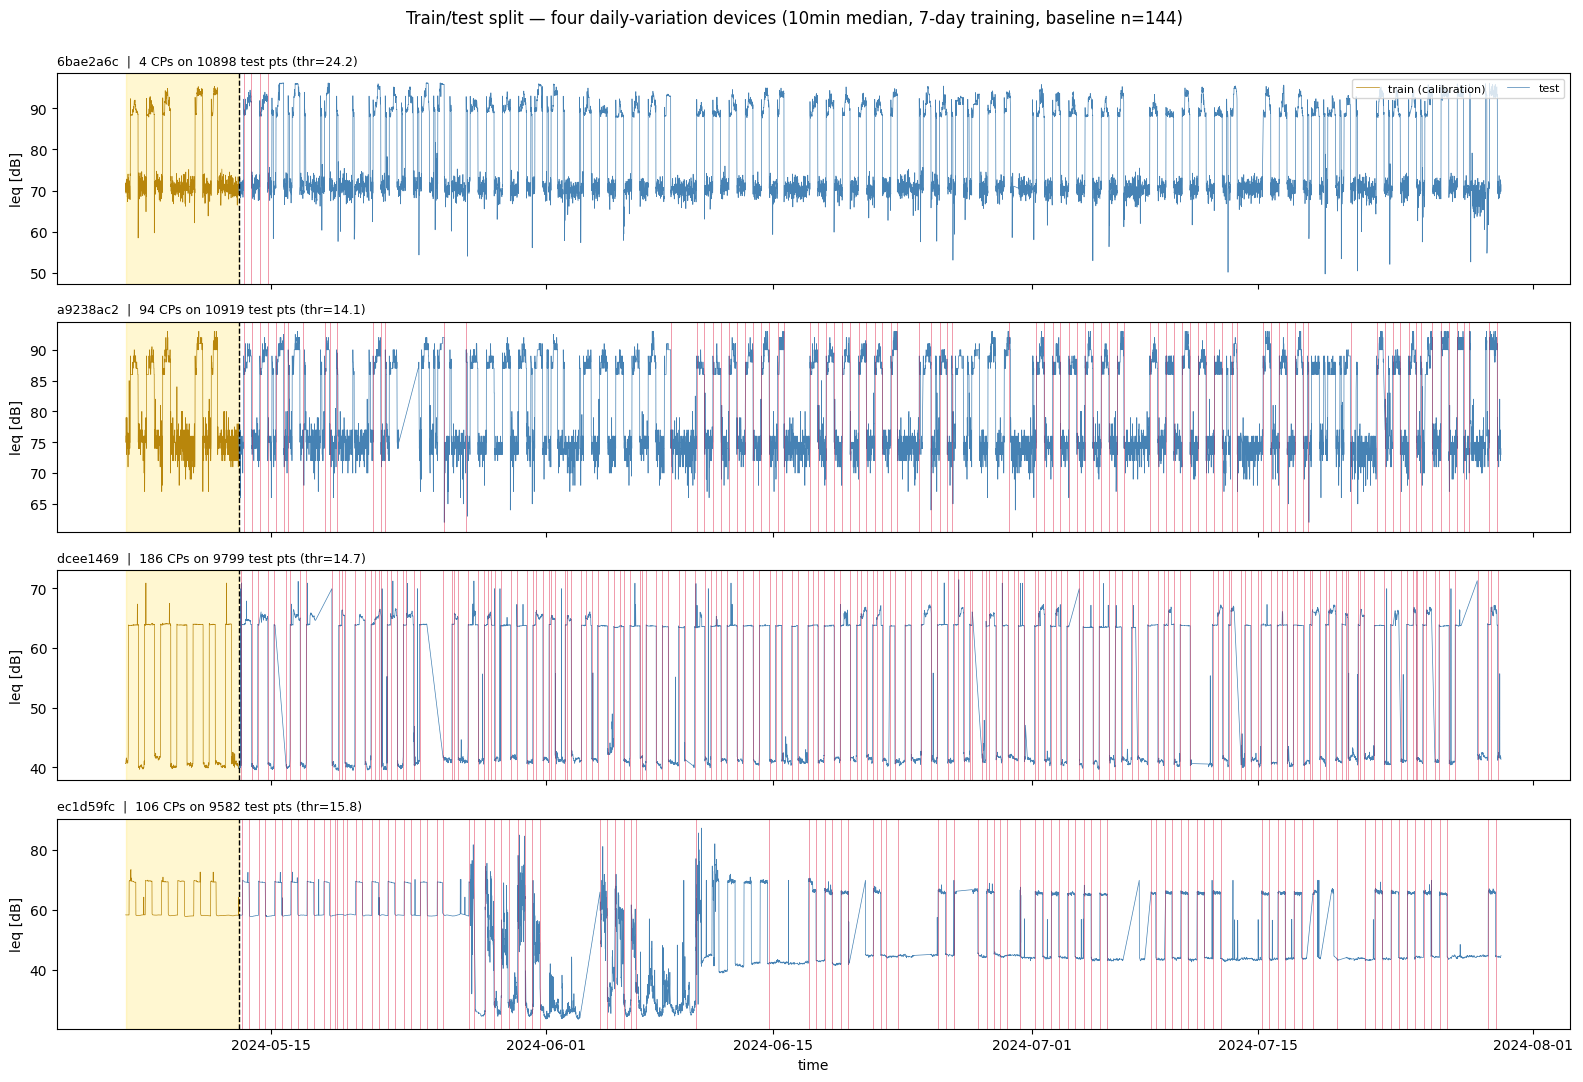

In [7]:
# Train/test split — four daily-variation devices (longer test + larger baseline)
# =============================================================================
TT_WINDOW = ("2024-05-06", "2024-07-29")  # ~12 weeks of data
TRAIN_DAYS = 7         # week-long training period
BASELINE_N = 144       # change-free baseline drawn from the training period
BASELINE_MARGIN = 1.5

fig, axes = plt.subplots(len(targets), 1, figsize=(16, 2.7 * len(targets)), sharex=True)
for ax, dev in zip(axes, targets):
    series = ss.xs(dev, level="device_id")["leq"].resample(AGG).median()
    window = series[TT_WINDOW[0] : TT_WINDOW[1]].dropna()
    split = window.index[0].normalize() + pd.Timedelta(days=TRAIN_DAYS)
    train_w = window[window.index < split]
    test_w = window[window.index >= split]
    test_d = test_w.values.astype(float)

    # Calibrate on the training period's quiet floor only (n=144 samples).
    detector = GridDetector(MeanCUSUMUnknownVariance())
    threshold = calibrate_detector_threshold_false_alarm_from_data(
        detector,
        training_data=quiet_floor(train_w, n=BASELINE_N, margin=BASELINE_MARGIN),
        false_alarm_probability=0.01,
        stream_len=144,
        n_paths=500,
        rng=42,
        parallel=False,
    )
    detector = with_calibrated_threshold(detector, threshold)
    thr = float(threshold[0])

    # Detect on the held-out test period.
    state = detector.init_state()
    offset = 0
    cps = []
    for i in range(len(test_d)):
        state, out = detector.update(state, np.array([test_d[i]]))
        if out["alarm"]:
            cp = offset + int(out["max_split_point"][0])
            cps.append(cp)
            offset = cp
            state = detector.init_state()
            for x in test_d[cp : i + 1]:
                state, _ = detector.update(state, np.array([x]))

    ax.axvspan(window.index[0], split, color="gold", alpha=0.18)
    ax.plot(train_w.index, train_w.values, color="darkgoldenrod", lw=0.5,
            label="train (calibration)")
    ax.plot(test_w.index, test_w.values, color="steelblue", lw=0.5, label="test")
    for c in cps:
        ax.axvline(test_w.index[c], color="crimson", lw=0.6, alpha=0.5)
    ax.axvline(split, color="black", lw=1.0, ls="--")
    ax.set_ylabel("leq [dB]")
    ax.set_title(f"{dev[:8]}  |  {len(cps)} CPs on {len(test_w)} test pts "
                 f"(thr={thr:.1f})", fontsize=9, loc="left")
axes[0].legend(loc="upper right", fontsize=8, ncol=2)
axes[-1].set_xlabel("time")
fig.suptitle(f"Train/test split — four daily-variation devices "
             f"({AGG} median, {TRAIN_DAYS}-day training, baseline n={BASELINE_N})", y=0.998)
fig.tight_layout()
plt.show()

### A seasonal device: train on a change-free window, test on the rest

`e52fa833` has no daily on/off cycle, but its overall sound level shifts with the
seasons (~69 dB in summer, ~57 dB in winter). The first two months (until
2024-07) are essentially stationary (std ~0.3 dB), so — unlike the daily-pattern
devices — we can use that whole block *directly* as the change-free calibration
baseline (no `quiet_floor` needed) and run detection on everything afterwards.
The detector stays quiet through the stable summer plateaus and fires at the
seasonal regime shifts and the noisier winter periods.

e52fa833: train 8,334 pts (std 0.31), test 92,182 pts -> 80 changepoints, thr=28.17


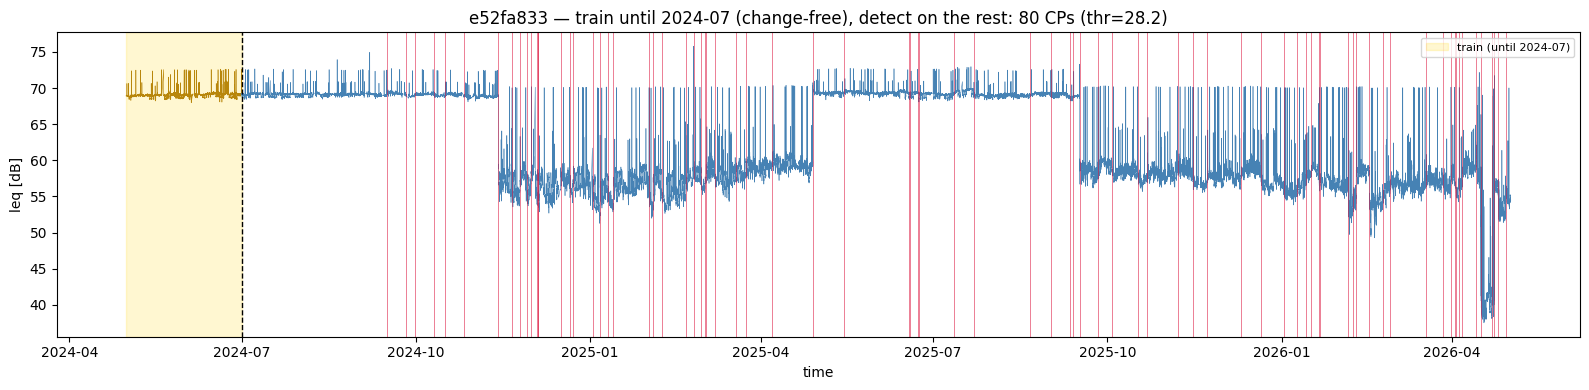

In [8]:
# Seasonal device: train on a change-free period, detect on the rest
# =============================================================================
dev = next(d for d in device_ids if d.startswith("e52fa833"))
full = ss.xs(dev, level="device_id")["leq"].resample(AGG).median().dropna()

SPLIT = pd.Timestamp("2024-07-01")
train = full[full.index < SPLIT]
test = full[full.index >= SPLIT]
tt, td = test.index, test.values.astype(float)

# The until-2024-07 block is itself change-free (std ~0.3 dB), so use it whole as
# the bootstrap baseline. Calibrate over a 1-week horizon (changes are seasonal).
detector = GridDetector(MeanCUSUMUnknownVariance())
threshold = calibrate_detector_threshold_false_alarm_from_data(
    detector,
    training_data=train.values.astype(float),
    false_alarm_probability=0.01,
    stream_len=1008,       # false-alarm horizon = 1 week
    n_paths=500,
    rng=42,
    parallel=False,
)
detector = with_calibrated_threshold(detector, threshold)
thr = float(threshold[0])

state = detector.init_state()
offset = 0
cps = []
for i in range(len(td)):
    state, out = detector.update(state, np.array([td[i]]))
    if out["alarm"]:
        cp = offset + int(out["max_split_point"][0])
        cps.append(cp)
        offset = cp
        state = detector.init_state()
        for x in td[cp : i + 1]:
            state, _ = detector.update(state, np.array([x]))

print(f"{dev[:8]}: train {len(train):,} pts (std {train.std():.2f}), "
      f"test {len(td):,} pts -> {len(cps)} changepoints, thr={thr:.2f}")

fig, ax = plt.subplots(figsize=(16, 4))
ax.axvspan(full.index[0], SPLIT, color="gold", alpha=0.18, label="train (until 2024-07)")
ax.plot(train.index, train.values, color="darkgoldenrod", lw=0.4)
ax.plot(tt, td, color="steelblue", lw=0.4)
for c in cps:
    ax.axvline(tt[c], color="crimson", lw=0.7, alpha=0.55)
ax.axvline(SPLIT, color="black", lw=1.0, ls="--")
ax.set_ylabel("leq [dB]")
ax.set_xlabel("time")
ax.set_title(f"{dev[:8]} — train until 2024-07 (change-free), detect on the rest: "
             f"{len(cps)} CPs (thr={thr:.1f})")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

### A day off as the calibration baseline (`6bae2a6c`)

The cells above ran on the **10-min median** aggregation. The two experiments
below instead use the **raw ~1-sample-per-minute stream** (no resampling), so the
detector sees the full ~1M-point stream it would face online — the realistic
streaming test.

`6bae2a6c` is busiest on weekdays and quietest on its "day off": Sunday is the
lowest-level day of the week (median ~70.4 dB vs ~73 dB on weekdays). Even on the
raw stream a Sunday stays essentially flat (std ~2.2 dB), whereas a weekday swings
through its full on/off cycle (std ~10 dB). So one whole Sunday is a clean
change-free training block: we calibrate the threshold on it directly and then
detect on the following two weeks of ordinary activity, expecting the alarms to
land on the recurring weekday on/off transitions.

6bae2a6c: raw Sunday baseline n=1335 (std 2.19), test 19,226 pts -> 59 changepoints, thr=14.64


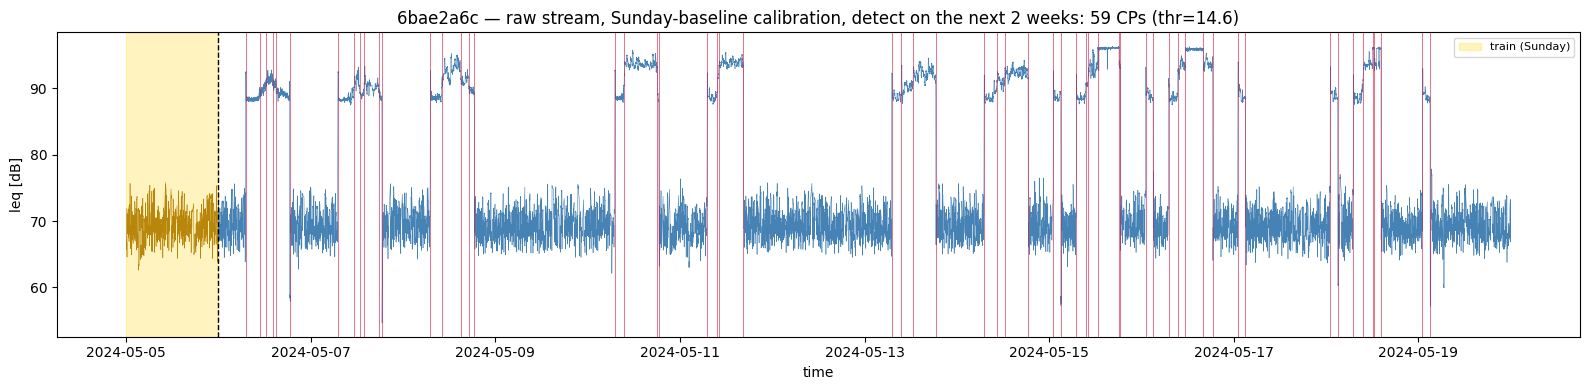

In [6]:
# Day-off baseline: calibrate on a Sunday, detect on the following two weeks
# =============================================================================
# Use the RAW ~1-min stream (no resampling) — the realistic online stream.
dev = next(d for d in device_ids if d.startswith("6bae2"))
series = ss.xs(dev, level="device_id")["leq"].dropna()

# Sunday is this device's quiet "day off" (lowest weekly level, no sustained
# weekday daytime plateau), so we calibrate the threshold directly on one whole
# Sunday and then detect on the following two weeks of normal activity.
TRAIN_DAY = pd.Timestamp("2024-05-05")    # first full Sunday in the record
assert TRAIN_DAY.dayofweek == 6, "TRAIN_DAY must be a Sunday"
train = series[TRAIN_DAY : TRAIN_DAY + pd.Timedelta(days=1)]
test = series[TRAIN_DAY + pd.Timedelta(days=1) : TRAIN_DAY + pd.Timedelta(days=15)]
tt, td = test.index, test.values.astype(float)

detector = GridDetector(MeanCUSUMUnknownVariance())
threshold = calibrate_detector_threshold_false_alarm_from_data(
    detector,
    training_data=train.values.astype(float),  # the whole change-free Sunday
    false_alarm_probability=0.01,
    stream_len=len(train)//2,  # false-alarm horizon = 1 day (the Sunday's own length)
    n_paths=2000,
    rng=42,
    parallel=False,
)

detector = with_calibrated_threshold(detector, threshold)
thr = float(threshold[0])

# Online detection with reset-and-replay at each estimated changepoint.
state = detector.init_state()
offset = 0
cps = []
for i in range(len(td)):
    state, out = detector.update(state, np.array([td[i]]))
    if out["alarm"]:
        cp = offset + int(out["max_split_point"][0])
        cps.append(cp)
        offset = cp
        state = detector.init_state()
        for x in td[cp : i + 1]:
            state, _ = detector.update(state, np.array([x]))

print(f"{dev[:8]}: raw Sunday baseline n={len(train)} (std {train.std():.2f}), "
      f"test {len(td):,} pts -> {len(cps)} changepoints, thr={thr:.2f}")

fig, ax = plt.subplots(figsize=(16, 4))
ax.axvspan(TRAIN_DAY, TRAIN_DAY + pd.Timedelta(days=1), color="gold", alpha=0.25,
           label="train (Sunday)")
ax.plot(train.index, train.values, color="darkgoldenrod", lw=0.4)
ax.plot(tt, td, color="steelblue", lw=0.4)
for c in cps:
    ax.axvline(tt[c], color="crimson", lw=0.7, alpha=0.6)
ax.axvline(TRAIN_DAY + pd.Timedelta(days=1), color="black", lw=1.0, ls="--")
ax.set_ylabel("leq [dB]")
ax.set_xlabel("time")
ax.set_title(f"{dev[:8]} — raw stream, Sunday-baseline calibration, detect on the "
             f"next 2 weeks: {len(cps)} CPs (thr={thr:.1f})")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

### Seasonal device with a longer training baseline

Again on the **raw ~1-min stream** (no resampling). `e52fa833`'s summer plateau is
long: it stays flat at ~69 dB (raw std ~0.4 dB) all the way from **May through
October 2024** before dropping into the noisier ~57 dB winter regime in November.
So we extend the change-free calibration baseline to that whole ~6-month summer
block (until 2024-11) — about 240k raw samples — and detect on everything from
November onward.

We expect the detector to fire at the autumn drop into winter, the spring recovery
back to the summer level, and the subsequent seasonal shifts. Note: calibrating
over a 1-week horizon on the raw stream (~9.6k samples × 500 paths) takes ~1 min.

e52fa833: train 241,459 pts (std 0.40), test 760,263 pts, stream_len=9592 -> 56 changepoints, thr=135.45
first detected change: 2024-11-13 11:49:51


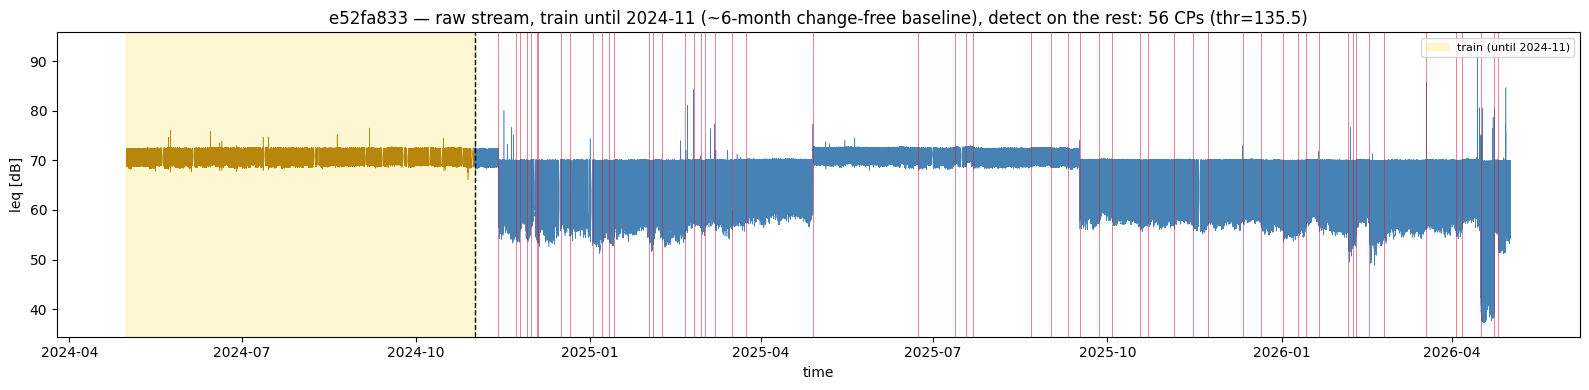

In [7]:
# Seasonal device, longer baseline: calibrate on the whole summer, detect the rest
# =============================================================================
# Use the RAW ~1-min stream (no resampling) — the full online stream (~1M pts).
dev = next(d for d in device_ids if d.startswith("e52fa833"))
full = ss.xs(dev, level="device_id")["leq"].dropna()

# Extend the change-free baseline to the full summer plateau (until 2024-11). The
# whole May–Oct block sits at ~69 dB with raw std ~0.4 dB, so it is still
# change-free — just a much longer calibration sample (~240k raw points).
SPLIT = pd.Timestamp("2024-11-01")
train = full[full.index < SPLIT]
test = full[full.index >= SPLIT]
tt, td = test.index, test.values.astype(float)

# 1-week false-alarm horizon, expressed in raw samples at this device's cadence.
samples_per_day = len(full) / ((full.index[-1] - full.index[0]).total_seconds() / 86400)
stream_len = int(round(7 * samples_per_day))

detector = GridDetector(MeanCUSUMUnknownVariance())
threshold = calibrate_detector_threshold_false_alarm_from_data(
    detector,
    training_data=train.values.astype(float),
    false_alarm_probability=0.01,
    stream_len=stream_len,   # ~1 week at the raw cadence (changes are seasonal)
    n_paths=2000,
    rng=42,
    parallel=False,
)
detector = with_calibrated_threshold(detector, threshold)
thr = float(threshold[0])

state = detector.init_state()
offset = 0
cps = []
for i in range(len(td)):
    state, out = detector.update(state, np.array([td[i]]))
    if out["alarm"]:
        cp = offset + int(out["max_split_point"][0])
        cps.append(cp)
        offset = cp
        state = detector.init_state()
        for x in td[cp : i + 1]:
            state, _ = detector.update(state, np.array([x]))

print(f"{dev[:8]}: train {len(train):,} pts (std {train.std():.2f}), "
      f"test {len(td):,} pts, stream_len={stream_len} -> {len(cps)} changepoints, "
      f"thr={thr:.2f}")
print(f"first detected change: {tt[cps[0]] if cps else 'none'}")

fig, ax = plt.subplots(figsize=(16, 4))
ax.axvspan(full.index[0], SPLIT, color="gold", alpha=0.18, label="train (until 2024-11)")
ax.plot(train.index, train.values, color="darkgoldenrod", lw=0.4)
ax.plot(tt, td, color="steelblue", lw=0.4)
for c in cps:
    ax.axvline(tt[c], color="crimson", lw=0.7, alpha=0.55)
ax.axvline(SPLIT, color="black", lw=1.0, ls="--")
ax.set_ylabel("leq [dB]")
ax.set_xlabel("time")
ax.set_title(f"{dev[:8]} — raw stream, train until 2024-11 (~6-month change-free "
             f"baseline), detect on the rest: {len(cps)} CPs (thr={thr:.1f})")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()